# Drift Detection — 01: Rule-Based (6 Sub-Approaches)

Evaluates six rule-based drift detectors on human-annotated persona data:

| # | Sub-approach | Philosophy |
|---|---|---|
| 0 | **Baseline (dual-trigger)** | Crash: single-step drop > δ. No-recovery: score < τ for ≥ C_min steps |
| 1 | **EMA** | Exponentially weighted running worry score |
| 2 | **CUSUM** | Cumulative sum — marbles in a jar |
| 3 | **Cosine Similarity** | Holistic direction check against value profile |
| 4 | **Control Charts** | Score outside mean ± nσ of a baseline period |
| 5 | **KL Divergence** | Distribution shift between baseline and recent window |

All approaches are rule-based: fixed formulas with tunable parameters, no learning.
The signal taxonomy (crash / fade / spike / no-recovery / onboarding-gap / rise) is specific
to rule-based detection — ML approaches (BOCPD, GP, HMM) subsume these patterns without naming them.

**Doc reference:** `docs/evolution/drift_detection.md § 3.1`


In [41]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.9)

# --- Load judge labels (204 personas, 1651 entries, integer {-1, 0, 1} scores) ---
# Using judge labels rather than human annotations: more data (all 204 personas vs 24),
# and clean integer scores (no averaging artefacts).

VALUE_COLS = [
    "alignment_self_direction", "alignment_stimulation", "alignment_hedonism",
    "alignment_achievement", "alignment_power", "alignment_security",
    "alignment_conformity", "alignment_tradition", "alignment_benevolence",
    "alignment_universalism",
]
SHORT_NAMES = [c.replace("alignment_", "") for c in VALUE_COLS]
DIM_LABELS  = ["SD", "ST", "HE", "AC", "PO", "SE", "CO", "TR", "BE", "UN"]

judge_df = pl.read_parquet("../../logs/judge_labels/judge_labels.parquet")
mean_df  = (
    judge_df
    .select(["persona_id", "t_index"] + VALUE_COLS)
    .with_columns([pl.col(c).cast(pl.Float64) for c in VALUE_COLS])
    .sort(["persona_id", "t_index"])
)

registry   = pl.read_parquet("../../logs/registry/personas.parquet").select(
                ["persona_id", "name", "core_values"])
id_to_name = dict(zip(registry["persona_id"].to_list(), registry["name"].to_list()))
id_to_core = dict(zip(registry["persona_id"].to_list(), registry["core_values"].to_list()))

persona_ids = sorted(mean_df["persona_id"].unique().to_list())
print(f"Loaded {len(judge_df)} judge-labelled entries across {len(persona_ids)} personas")

# --- Sample: verify input scores look correct ---
# Pick first persona with ≥5 entries so the sample is representative
sample_pid = next(
    pid for pid in persona_ids
    if mean_df.filter(pl.col("persona_id") == pid).height >= 5
)
sample_data = mean_df.filter(pl.col("persona_id") == sample_pid).head(5)
print(f"\nSample scores (first 5 entries) for '{id_to_name.get(sample_pid, sample_pid)}':")
print(f"  Core values: {id_to_core.get(sample_pid, [])}")
print(sample_data.select(["t_index"] + VALUE_COLS))
print("  Scores are integers in {{-1, 0, +1}} across all 10 Schwartz dimensions")


def get_persona_matrix(pid: str) -> tuple[list[int], np.ndarray]:
    pdata = mean_df.filter(pl.col("persona_id") == pid).sort("t_index")
    return pdata["t_index"].to_list(), np.array([pdata[c].to_list() for c in VALUE_COLS]).T


def get_profile_weights(pid: str) -> np.ndarray:
    core = id_to_core.get(pid, [])
    name_to_idx = {s.lower().replace("-", "_"): i for i, s in enumerate(SHORT_NAMES)}
    w = np.zeros(10)
    for v in core:
        key = v.lower().replace("-", "_").replace(" ", "_")
        if key in name_to_idx:
            w[name_to_idx[key]] = 1.0
    if w.sum() > 0:
        w /= w.sum()
    return w


def core_dim_indices(weights: np.ndarray, w_min: float = 0.15) -> list[int]:
    return [j for j, wj in enumerate(weights) if wj >= w_min]


Loaded 1651 judge-labelled entries across 204 personas

Sample scores (first 5 entries) for 'Megan Torres':
  Core values: ['Achievement', 'Benevolence']
shape: (5, 11)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ t_index ┆ alignment_ ┆ alignment ┆ alignment ┆ … ┆ alignment ┆ alignment ┆ alignment ┆ alignment │
│ ---     ┆ self_direc ┆ _stimulat ┆ _hedonism ┆   ┆ _conformi ┆ _traditio ┆ _benevole ┆ _universa │
│ i64     ┆ tion       ┆ ion       ┆ ---       ┆   ┆ ty        ┆ n         ┆ nce       ┆ lism      │
│         ┆ ---        ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ f64        ┆ f64       ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.0        ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ 1       ┆ 0.0        

## Approach 0: Baseline (dual-trigger)

The simplest possible implementation from `docs/vif/04_uncertainty_logic.md`:
- **Crash:** single-step drop in profile-weighted alignment > δ
- **No-recovery:** alignment stays below τ_low for ≥ C_min consecutive steps

Serves as the benchmark. If this meets targets (≥80% hit rate, <20% FPR) the more complex sub-approaches are unnecessary.

In [42]:
def detect_baseline(
    scores: np.ndarray,
    weights: np.ndarray,
    delta: float = 0.5,
    tau_low: float = -0.4,
    c_min: int = 3,
    w_min: float = 0.15,
) -> dict:
    """Dual-trigger baseline: crash + no-recovery per core dimension."""
    T, K = scores.shape
    alerts = []          # (t, j, kind)  kind = 'crash' | 'no_recovery'
    state = np.zeros(K)  # consecutive low-score counter per dimension

    scalar = scores @ weights  # profile-weighted scalar alignment

    for t in range(1, T):
        drop = scalar[t - 1] - scalar[t]
        if drop > delta:
            alerts.append((t, -1, "crash"))  # j=-1 means holistic

        for j in range(K):
            if weights[j] < w_min:
                state[j] = 0
                continue
            if scores[t, j] < tau_low:
                state[j] += 1
                if state[j] >= c_min:
                    alerts.append((t, j, "no_recovery"))
            else:
                state[j] = 0

    return {"alerts": alerts, "scalar": scalar}


## Approach 1: EMA (Exponential Moving Average)

A running 'worry score' per dimension. Each week, mix in the new misalignment but let old worry fade:
`worry = α × new + (1-α) × old`. Alert when worry > threshold.

- Detects **gradual fades** well (accumulates slowly).
- Weak on isolated crashes (a single bad week only partially fills the score).

In [43]:
def detect_ema(
    scores: np.ndarray,
    weights: np.ndarray,
    alpha: float = 0.3,
    threshold: float = 0.10,
    w_min: float = 0.15,
) -> dict:
    T, K = scores.shape
    ema = np.zeros(K)
    ema_history = np.zeros((T, K))
    alerts = []

    for t in range(T):
        for j in range(K):
            if weights[j] < w_min:
                continue
            misalign = max(0.0, -scores[t, j])
            signal = weights[j] * misalign
            ema[j] = alpha * signal + (1 - alpha) * ema[j]
            if ema[j] > threshold:
                alerts.append((t, j))
        ema_history[t] = ema.copy()

    return {"alerts": alerts, "ema_history": ema_history}


## Approach 2: CUSUM (Cumulative Sum)

Every bad week adds a marble to a jar. Every okay week removes one (but never below zero). If the jar fills past a threshold, something systemic is happening.

- Detects **sustained small shifts** that individually look harmless.
- Resets only on explicit drain — memory is longer than EMA.

In [44]:
def detect_cusum(
    scores: np.ndarray,
    weights: np.ndarray,
    k: float = 0.3,
    h: float = 1.5,
    w_min: float = 0.15,
) -> dict:
    T, K = scores.shape
    jar = np.zeros(K)
    jar_history = np.zeros((T, K))
    alerts = []

    for t in range(T):
        for j in range(K):
            if weights[j] < w_min:
                continue
            misalign = weights[j] * max(0.0, -scores[t, j])
            jar[j] = max(0.0, jar[j] + misalign - k)
            if jar[j] > h:
                alerts.append((t, j))
        jar_history[t] = jar.copy()

    return {"alerts": alerts, "jar_history": jar_history}


## Approach 3: Cosine Similarity

Forget magnitudes — just ask: is the behaviour vector pointing in the same direction as the value profile?
A negative cosine similarity means behaviour is anti-correlated with declared values.

- Holistic (not per-dimension).
- Immediate — detects direction reversal in a single step.
- Weak on duration (can't track whether the reversal persists).

In [45]:
def detect_cosine(
    scores: np.ndarray,
    weights: np.ndarray,
    threshold: float = 0.0,
) -> dict:
    T, K = scores.shape
    cosines = []
    alerts = []

    for t in range(T):
        a = scores[t]
        norm = np.linalg.norm(weights) * np.linalg.norm(a)
        cos = float(np.dot(weights, a) / norm) if norm > 1e-8 else 0.0
        cosines.append(cos)
        if cos < threshold:
            alerts.append(t)

    return {"alerts": alerts, "cosines": cosines}


## Approach 4: Control Charts

Learn what 'normal' looks like from a baseline period, then flag any score outside the expected range.
Uses mean ± nσ control limits.

- Per-dimension.
- Strong on **crashes** (immediate LCL breach after stable baseline).
- Requires a meaningful baseline period (first few steps).

In [46]:
def detect_control_chart(
    scores: np.ndarray,
    weights: np.ndarray,
    baseline_end: int = 3,
    n_sigma: float = 2.0,
    w_min: float = 0.15,
) -> dict:
    T, K = scores.shape
    alerts = []
    lcls = np.full(K, np.nan)

    if baseline_end >= T:
        return {"alerts": [], "lcls": lcls}

    baseline = scores[:baseline_end]
    mu   = baseline.mean(axis=0)
    sigma = baseline.std(axis=0)

    for j in range(K):
        if weights[j] >= w_min:
            lcls[j] = mu[j] - n_sigma * sigma[j]

    for t in range(baseline_end, T):
        for j in range(K):
            if weights[j] < w_min or np.isnan(lcls[j]):
                continue
            if scores[t, j] < lcls[j]:
                alerts.append((t, j))

    return {"alerts": alerts, "lcls": lcls, "mu": mu, "sigma": sigma}


## Approach 5: KL Divergence

Compare the *mix* of scores in a sliding window against the baseline mix. Even if the mean stays similar,
a shift in the distribution (e.g., consistently -1 instead of a mix of +1 and 0) triggers an alert.

- Captures both **level** and **shape** changes.
- Needs enough data in both baseline and comparison windows.
- Slower to detect (needs window to fill).

In [47]:
def _scores_to_dist(vals: np.ndarray, smoothing: float = 0.05) -> np.ndarray:
    bins = [-1.5, -0.5, 0.5, 1.5]
    counts, _ = np.histogram(vals, bins=bins)
    dist = counts.astype(float) + smoothing
    return dist / dist.sum()


def detect_kl_divergence(
    scores: np.ndarray,
    weights: np.ndarray,
    baseline_end: int = 3,
    window: int = 3,
    kl_threshold: float = 0.15,
    w_min: float = 0.15,
) -> dict:
    from scipy.special import rel_entr
    T, K = scores.shape
    alerts = []
    kl_history = np.zeros((T, K))

    for j in range(K):
        if weights[j] < w_min:
            continue
        baseline_dist = _scores_to_dist(scores[:baseline_end, j])
        for t in range(baseline_end + window, T + 1):
            recent_dist = _scores_to_dist(scores[t - window:t, j])
            kl = float(np.sum(rel_entr(recent_dist, baseline_dist)))
            kl_history[t - 1, j] = kl
            if kl > kl_threshold:
                alerts.append((t - 1, j))

    return {"alerts": alerts, "kl_history": kl_history}


## Run All 6 Sub-Approaches

Filter to personas with ≥5 steps. Profile weights are derived equally from declared core values.

In [48]:
MIN_STEPS = 5
APPROACH_KEYS  = ["baseline", "ema", "cusum", "cosine", "control_chart", "kl"]
APPROACH_NAMES = ["Baseline", "EMA", "CUSUM", "Cosine", "Control Chart", "KL Div"]

results = {}

for pid in persona_ids:
    t_idx, matrix = get_persona_matrix(pid)
    T = len(t_idx)
    if T < MIN_STEPS:
        continue

    w = get_profile_weights(pid)
    baseline_end = max(2, min(4, T // 3))

    results[pid] = {
        "name":        id_to_name.get(pid, pid[:8]),
        "core":        id_to_core.get(pid, []),
        "T":           T,
        "t_idx":       t_idx,
        "matrix":      matrix,
        "weights":     w,
        "baseline_end": baseline_end,
        "baseline":    detect_baseline(matrix, w),
        "ema":         detect_ema(matrix, w),
        "cusum":       detect_cusum(matrix, w),
        "cosine":      detect_cosine(matrix, w),
        "control_chart": detect_control_chart(matrix, w, baseline_end=baseline_end),
        "kl":          detect_kl_divergence(matrix, w, baseline_end=baseline_end),
    }

print(f"Ran 6 sub-approaches on {len(results)} personas (≥{MIN_STEPS} steps)\n")
hdr = f"{'Persona':<25s}  {'Core':<28s}  T  " + "  ".join(f"{n:>5s}" for n in APPROACH_NAMES)
print(hdr)
print("-" * len(hdr))
for pid, r in results.items():
    counts = [len(r[k]["alerts"]) for k in APPROACH_KEYS]
    core_str = ", ".join(r["core"])
    print(f"{r['name']:<25s}  {core_str:<28s}  {r['T']:2d}  " +
          "  ".join(f"{c:>5d}" for c in counts))


Ran 6 sub-approaches on 180 personas (≥5 steps)

Persona                    Core                          T  Baseline    EMA  CUSUM  Cosine  Control Chart  KL Div
-----------------------------------------------------------------------------------------------------------------
Megan Torres               Achievement, Benevolence      10      2      5      0      0      2     10
Tariq Mansour              Power, Benevolence             9      0      0      0      0      0      6
Noor Haddad                Self-Direction, Tradition     12      0      6      0      2      1     11
Lukas Vermeer              Tradition                     12      1      0      0      0      0      6
Patricia Moreno            Universalism                   6      2      4      0      1      0      2
Roberto Espinoza           Security                       6      0      0      0      0      0      0
Chen Wei-Lin               Stimulation                    8      1      0      0      0      0      4
Mathilde 

## Consensus Ground Truth

Rather than manually labelling crisis points, use **cross-approach agreement** as a proxy for ground truth.
If ≥4 of 6 sub-approaches independently flag the same `(persona, t_index)`, treat it as a high-confidence crisis.

```
consensus_score = number of approaches flagging (pid, t)   # 0–6
strong  → score ≥ 4   (majority agreement)
weak    → score ∈ {2, 3}
none    → score ≤ 1
```

This produces labels without manual work and covers all personas with ≥5 steps.

In [49]:
def get_alert_steps(r: dict, key: str) -> set[int]:
    """Return the set of t-steps (0-indexed within persona) where any alert fired."""
    alerts = r[key]["alerts"]
    if not alerts:
        return set()
    if isinstance(alerts[0], tuple):
        return {a[0] for a in alerts}
    return set(alerts)   # cosine: bare ints


consensus = {}   # pid -> {t: score}

for pid, r in results.items():
    T = r["T"]
    step_votes = {t: 0 for t in range(T)}
    for key in APPROACH_KEYS:
        for t in get_alert_steps(r, key):
            if t in step_votes:
                step_votes[t] += 1
    consensus[pid] = step_votes

# Classify each step
def classify(score: int) -> str:
    if score >= 4: return "strong"
    if score >= 2: return "weak"
    return "none"

# Summary
strong_total = sum(1 for pid, sv in consensus.items()
                   for score in sv.values() if score >= 4)
weak_total   = sum(1 for pid, sv in consensus.items()
                   for score in sv.values() if 2 <= score < 4)

print(f"Consensus summary across {len(consensus)} personas:")
print(f"  Strong crisis steps (≥4 agree): {strong_total}")
print(f"  Weak crisis steps   (2-3 agree): {weak_total}")
print()
for pid, sv in consensus.items():
    strong_steps = [t for t, s in sv.items() if s >= 4]
    if strong_steps:
        name = results[pid]["name"]
        print(f"  {name:<25s} strong at t={strong_steps}")


Consensus summary across 180 personas:
  Strong crisis steps (≥4 agree): 121
  Weak crisis steps   (2-3 agree): 364

  Karim Nazari              strong at t=[3, 5]
  Valentina Reyes           strong at t=[3]
  Soo-jin Park              strong at t=[2, 4, 5]
  Joon-ho Park              strong at t=[3, 5, 7]
  Tariq Hadid               strong at t=[3, 6, 9]
  Arjun Rathore             strong at t=[8]
  Chen Wei-Lin              strong at t=[4]
  Matthijs van der Berg     strong at t=[7]
  Nasser Haddad             strong at t=[4]
  Margot van den Berg       strong at t=[7, 9]
  Camila Restrepo           strong at t=[6]
  Valentina Reyes           strong at t=[5]
  Layla Haddad              strong at t=[3, 7]
  Tariq Al-Mohammadi        strong at t=[4, 5, 7, 9]
  Rohan Mehta               strong at t=[2, 4, 5]
  Nisha Agarwal             strong at t=[5, 6]
  Tariq Al-Mansouri         strong at t=[5, 6, 9]
  Klaus Mertens             strong at t=[3]
  Yuki Tanaka               strong at t=

## Metrics: Score Each Sub-Approach Against Consensus

For each sub-approach, compute hit rate, precision, F1, FPR, and first-alert latency against the consensus strong-crisis labels.

| Metric | Target |
|---|---|
| Hit Rate | ≥ 80% |
| Precision | > 60% |
| F1 | > 0.5 |
| FPR | < 20% |
| First-alert latency | ≤ 2 steps |

In [50]:
from dataclasses import dataclass

@dataclass
class Metrics:
    hit_rate:  float
    precision: float
    f1:        float
    fpr:       float
    latency:   float   # mean steps after first strong-crisis step


def score_approach(key: str, threshold: int = 4) -> Metrics:
    tp = fp = fn = tn = 0
    latencies = []

    for pid, r in results.items():
        sv = consensus[pid]
        crisis_steps = {t for t, s in sv.items() if s >= threshold}
        non_crisis   = {t for t, s in sv.items() if s < threshold}

        alerted = get_alert_steps(r, key)

        tp += len(alerted & crisis_steps)
        fp += len(alerted & non_crisis)
        fn += len(crisis_steps - alerted)
        tn += len(non_crisis - alerted)

        # Latency: steps between first crisis step and first alert (if any)
        if crisis_steps and alerted:
            first_crisis = min(crisis_steps)
            first_alert  = min((t for t in alerted if t >= first_crisis), default=None)
            if first_alert is not None:
                latencies.append(first_alert - first_crisis)

    hit_rate  = tp / max(tp + fn, 1)
    precision = tp / max(tp + fp, 1)
    f1        = 2 * hit_rate * precision / max(hit_rate + precision, 1e-9)
    fpr       = fp / max(fp + tn, 1)
    latency   = float(np.mean(latencies)) if latencies else float("nan")
    return Metrics(hit_rate, precision, f1, fpr, latency)


print(f"{'Approach':<15s}  {'Hit%':>6s}  {'Prec%':>6s}  {'F1':>6s}  {'FPR%':>6s}  {'Lat':>5s}")
print("-" * 58)
metrics = {}
for key, name in zip(APPROACH_KEYS, APPROACH_NAMES):
    m = score_approach(key)
    metrics[key] = m
    hit_ok  = "✓" if m.hit_rate  >= 0.80 else " "
    prec_ok = "✓" if m.precision >= 0.60 else " "
    fpr_ok  = "✓" if m.fpr       <= 0.20 else " "
    print(f"{name:<15s}  {m.hit_rate*100:>5.1f}{hit_ok}  "
          f"{m.precision*100:>5.1f}{prec_ok}  "
          f"{m.f1:>6.3f}  "
          f"{m.fpr*100:>5.1f}{fpr_ok}  "
          f"{m.latency:>5.1f}")


Approach           Hit%   Prec%      F1    FPR%    Lat
----------------------------------------------------------
Baseline          87.6✓   44.2    0.587    9.2✓    0.0
EMA              100.0✓   20.6    0.342   32.0     0.0
CUSUM             48.8    57.3    0.527    3.0✓    0.8
Cosine            92.6✓   47.1    0.624    8.7✓    0.0
Control Chart     52.9    37.9    0.441    7.2✓    0.0
KL Div            67.8    15.4    0.250   31.1     0.8


## Per-Persona Alert Dashboard

For each persona: alignment scores on core dimensions across time, with alert markers per sub-approach.

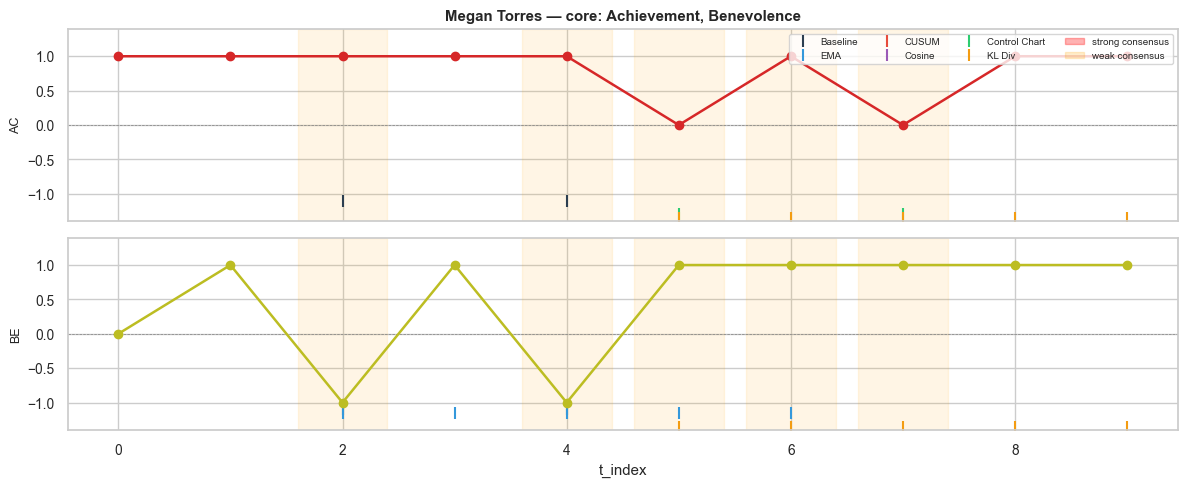

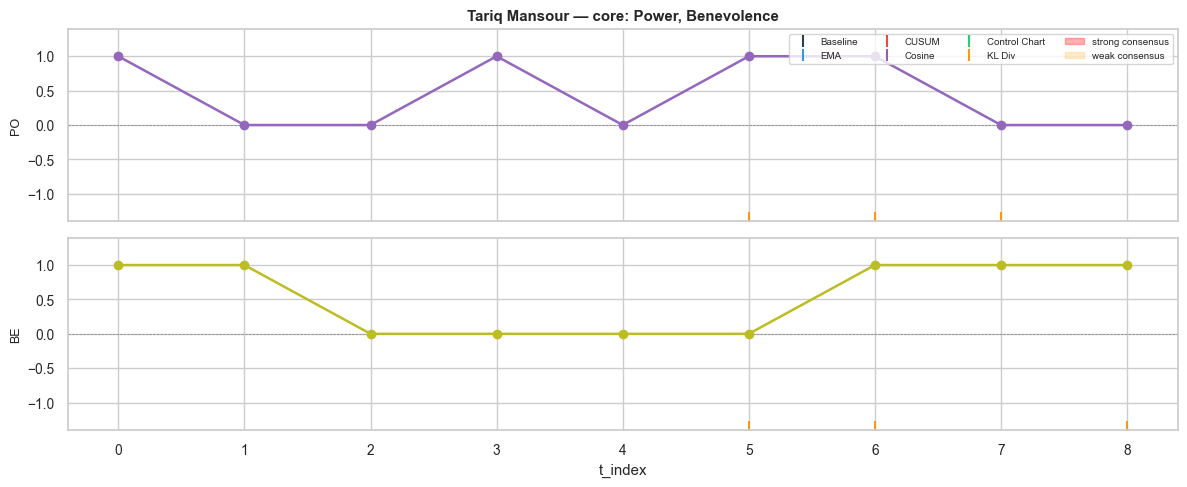

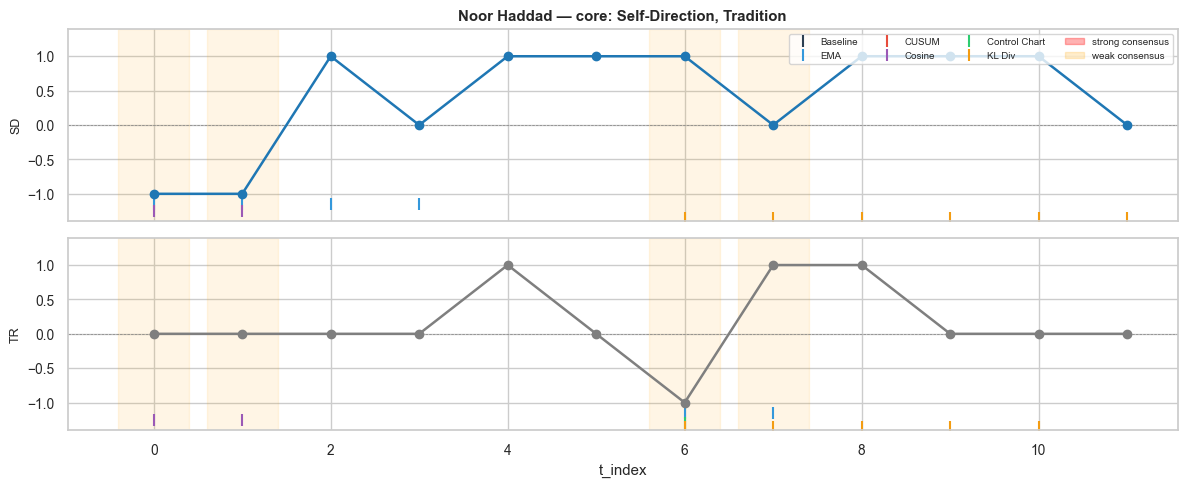

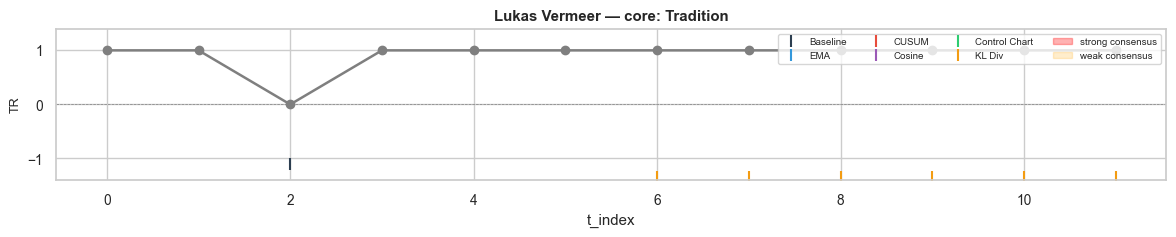

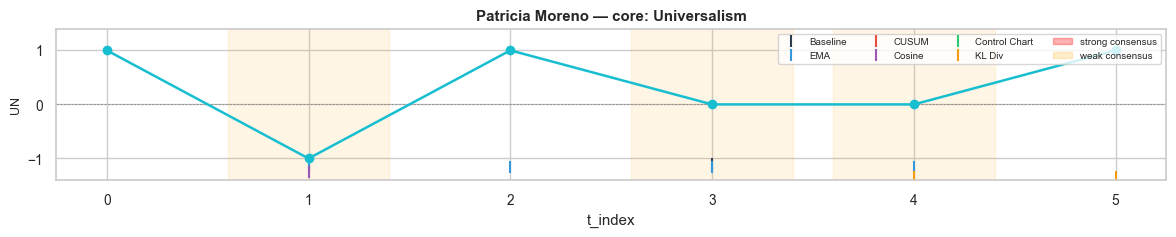

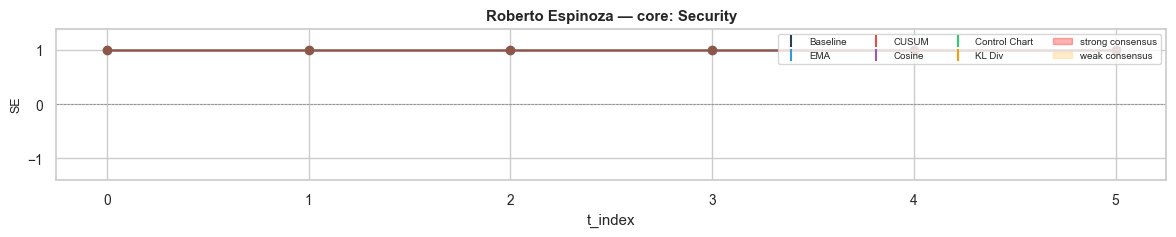

In [51]:
palette = sns.color_palette("tab10", n_colors=10)
APPROACH_COLORS = ["#2c3e50", "#3498db", "#e74c3c", "#9b59b6", "#2ecc71", "#f39c12"]


def plot_persona(pid: str):
    r = results[pid]
    matrix  = r["matrix"]
    weights = r["weights"]
    T       = r["T"]
    core_j  = core_dim_indices(weights)
    if not core_j:
        return

    fig, axes = plt.subplots(len(core_j), 1, figsize=(12, 2.5 * len(core_j)), sharex=True)
    if len(core_j) == 1:
        axes = [axes]

    for ax, j in zip(axes, core_j):
        ax.plot(range(T), matrix[:, j], "o-", color=palette[j], lw=1.8,
                label=DIM_LABELS[j], zorder=3)
        ax.axhline(0, color="grey", lw=0.5, ls="--")
        ax.set_ylim(-1.4, 1.4)
        ax.set_ylabel(DIM_LABELS[j], fontsize=9)

        # Mark consensus crisis steps
        sv = consensus[pid]
        for t, score in sv.items():
            if score >= 4:
                ax.axvspan(t - 0.4, t + 0.4, color="red", alpha=0.15, zorder=1)
            elif score >= 2:
                ax.axvspan(t - 0.4, t + 0.4, color="orange", alpha=0.10, zorder=1)

        # Mark alerts per approach (offset markers)
        for idx, (key, name, col) in enumerate(zip(APPROACH_KEYS, APPROACH_NAMES, APPROACH_COLORS)):
            alerted = get_alert_steps(r, key)
            alerted_j = alerted  # cosine is holistic; others may be per-dim
            if isinstance(r[key]["alerts"], list) and r[key]["alerts"] and isinstance(r[key]["alerts"][0], tuple):
                alerted_j = {a[0] for a in r[key]["alerts"] if a[1] in (j, -1)}
            for t in alerted_j:
                ax.plot(t, -1.1 - idx * 0.05, "|", color=col,
                        ms=8, mew=1.5, label=name if t == min(alerted_j) else "")

    axes[0].set_title(f"{r['name']} — core: {', '.join(r['core'])}", fontweight="bold")
    axes[-1].set_xlabel("t_index")

    # Legend
    from matplotlib.lines import Line2D
    handles = [Line2D([0], [0], color=c, marker="|", ms=8, mew=1.5, ls="none", label=n)
               for c, n in zip(APPROACH_COLORS, APPROACH_NAMES)]
    from matplotlib.patches import Patch
    handles += [Patch(color="red", alpha=0.3, label="strong consensus"),
                Patch(color="orange", alpha=0.2, label="weak consensus")]
    axes[0].legend(handles=handles, fontsize=7, ncol=4, loc="upper right")

    plt.tight_layout()
    plt.show()


for pid in list(results.keys())[:6]:   # show first 6
    plot_persona(pid)


## Agreement Heatmap

For each persona, what fraction of monitored steps did each sub-approach alert on?

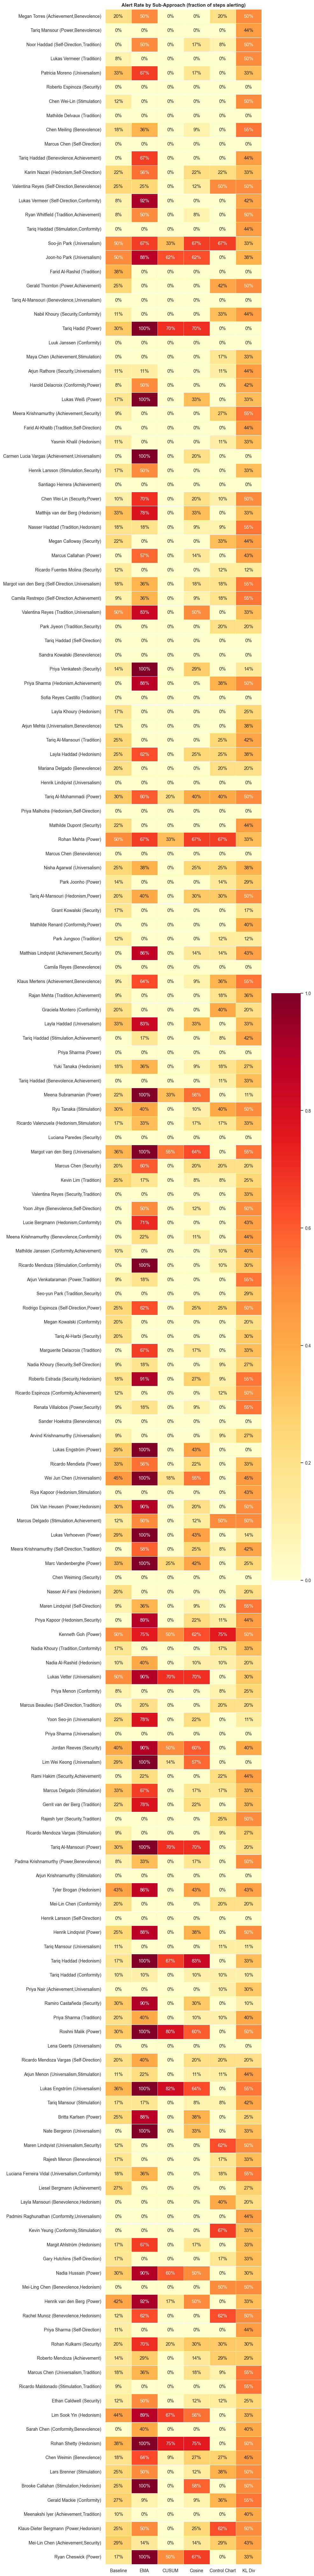

In [52]:
def alert_rate(r: dict, key: str) -> float:
    T = r["T"]
    alerted = get_alert_steps(r, key)
    return len(alerted) / max(T, 1)


persona_labels = [f"{r['name']} ({','.join(r['core'])})" for r in results.values()]
rate_matrix = np.array([
    [alert_rate(r, k) for k in APPROACH_KEYS]
    for r in results.values()
])

fig, ax = plt.subplots(figsize=(10, max(5, len(results) * 0.45)))
sns.heatmap(rate_matrix, ax=ax,
            xticklabels=APPROACH_NAMES, yticklabels=persona_labels,
            cmap="YlOrRd", vmin=0, vmax=1, annot=True, fmt=".0%",
            linewidths=0.5, linecolor="white")
ax.set_title("Alert Rate by Sub-Approach (fraction of steps alerting)", fontweight="bold")
plt.tight_layout()
plt.show()


## Summary

| Sub-approach | Detects Rut? | Detects Crash? | Latency | Memory | Per-dim? |
|---|:---:|:---:|:---:|:---:|:---:|
| **Baseline** | ✓ (no-recovery counter) | ✓ (single-step drop) | Immediate | None | Crash: no; Rut: yes |
| **EMA** | ✓ (strong) | Weak (fades) | 2-3 steps | Exponential decay | Yes |
| **CUSUM** | ✓ (strong) | Weak (needs accumulation) | 2-3 steps | Indefinite (until reset) | Yes |
| **Cosine** | Weak (no duration) | ✓ (instant) | Immediate | None | No (holistic) |
| **Control Chart** | Medium (run rule) | ✓ (LCL breach) | Immediate after baseline | Fixed baseline | Yes |
| **KL Div** | ✓ (distribution shift) | Weak (needs window) | Slow | Sliding window | Yes |

See `docs/evolution/drift_detection.md § 3.1` for full parameter grid and selection rationale.